In [7]:
#imports
import os
import wfdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    ConfusionMatrixDisplay
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D
from tensorflow.keras.layers import Flatten, Dense, Dropout

In [2]:
#Load and create dataset
import os

dataset_file = "ecg_dataset.npz"

if os.path.exists(dataset_file):
    print("Loading saved dataset...")

    data = np.load(dataset_file)
    X = data["X"]
    y = data["y"]
    groups = data["groups"]

else:
    print("Creating dataset from PhysioNet...")

    record_ids = wfdb.get_record_list("mitdb")

    print("Number of records:", len(record_ids))
    print("First records:", record_ids[:5])

    window_before = 90
    window_after = 90

    X, y, groups = [], [], []

    for rec_id in record_ids:
        print("Loading record:", rec_id)

        record = wfdb.rdrecord(rec_id, pn_dir="mitdb")
        annotation = wfdb.rdann(rec_id, "atr", pn_dir="mitdb")

        signal = record.p_signal[:, 0]

        for sample, symbol in zip(annotation.sample, annotation.symbol):
            if symbol in ["N", "V"]:
                start = sample - window_before
                end = sample + window_after

                if start >= 0 and end < len(signal):
                    X.append(signal[start:end])
                    y.append(1 if symbol == "V" else 0)
                    groups.append(rec_id)

    X = np.array(X)
    y = np.array(y)
    groups = np.array(groups)

    X = (X - X.mean(axis=1, keepdims=True)) / (
        X.std(axis=1, keepdims=True) + 1e-8
    )

    X = X[..., np.newaxis]

    np.savez_compressed(dataset_file, X=X, y=y, groups=groups)

    print("Dataset saved successfully.")

print("X shape:", X.shape)
print("y shape:", y.shape)
print("groups shape:", groups.shape)
print("Class counts:", np.bincount(y))
print("Number of records:", len(np.unique(groups)))

Loading saved dataset...
X shape: (82162, 180, 1)
y shape: (82162,)
groups shape: (82162,)
Class counts: [75033  7129]
Number of records: 47


In [3]:
#Filtering records with both classes
valid_records = []

min_normal = 50
min_pvc = 20

for rec in np.unique(groups):
    idx = groups == rec

    normal_count = np.sum(y[idx] == 0)
    pvc_count = np.sum(y[idx] == 1)

    if normal_count >= min_normal and pvc_count >= min_pvc:
        valid_records.append(rec)

valid_records = np.array(valid_records)

valid_idx = np.isin(groups, valid_records)

X = X[valid_idx]
y = y[valid_idx]
groups = groups[valid_idx]

print("Valid records:", valid_records)
print("Number of valid records:", len(valid_records))
print("Filtered X shape:", X.shape)
print("Filtered class counts:", np.bincount(y))

Valid records: ['105' '106' '114' '116' '119' '200' '201' '203' '205' '208' '210' '213'
 '215' '217' '219' '221' '223' '228' '233']
Number of valid records: 19
Filtered X shape: (44861, 180, 1)
Filtered class counts: [38308  6553]


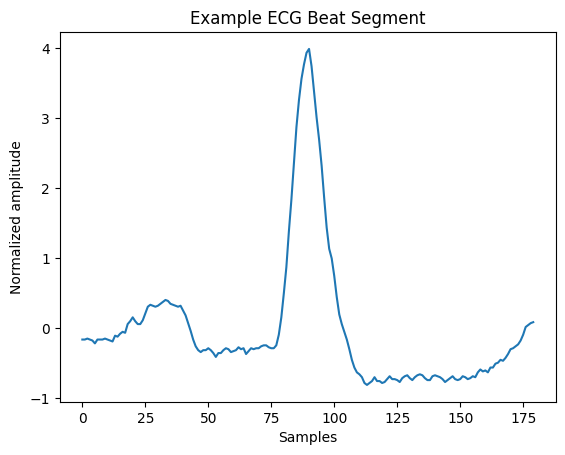

In [4]:
#Plotting one example beat
plt.plot(X[0].squeeze())
plt.title("Example ECG Beat Segment")
plt.xlabel("Samples")
plt.ylabel("Normalized amplitude")
plt.show()

In [5]:
#Building 1D CNN
def build_model(input_shape):
    model = Sequential([
        Input(shape=input_shape),

        Conv1D(32, kernel_size=5, activation="relu"),
        MaxPooling1D(pool_size=2),

        Conv1D(64, kernel_size=5, activation="relu"),
        MaxPooling1D(pool_size=2),

        Flatten(),

        Dense(64, activation="relu"),
        Dropout(0.3),

        Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [6]:
#Leave-one-record-out evaluation
logo = LeaveOneGroupOut()

fold_results = []
all_y_true = []
all_y_pred = []

for fold, (train_idx, test_idx) in enumerate(logo.split(X, y, groups), start=1):
    test_record = np.unique(groups[test_idx])[0]

    print(f"\nFold {fold} | Test record: {test_record}")

    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    model = build_model(input_shape=(X_train.shape[1], 1))

    model.fit(
        X_train,
        y_train,
        epochs=5,
        batch_size=32,
        validation_split=0.2,
        verbose=0
    )

    y_prob = model.predict(X_test, verbose=0)
    y_pred = (y_prob > 0.5).astype(int).flatten()

    acc = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    print("Accuracy:", round(acc, 4))
    print("PVC Recall:", round(recall, 4))
    print("PVC F1:", round(f1, 4))

    fold_results.append({
        "fold": fold,
        "test_record": test_record,
        "accuracy": acc,
        "precision_pvc": precision,
        "recall_pvc": recall,
        "f1_pvc": f1,
        "n_test_samples": len(y_test),
        "normal_count": int(np.sum(y_test == 0)),
        "pvc_count": int(np.sum(y_test == 1))
    })

    all_y_true.extend(y_test)
    all_y_pred.extend(y_pred)


Fold 1 | Test record: 105
Accuracy: 0.9727
PVC Recall: 0.1463
PVC F1: 0.1463

Fold 2 | Test record: 106
Accuracy: 0.9443
PVC Recall: 0.7846
PVC F1: 0.8784

Fold 3 | Test record: 114
Accuracy: 0.8621
PVC Recall: 1.0
PVC F1: 0.2507

Fold 4 | Test record: 116
Accuracy: 0.9979
PVC Recall: 0.9817
PVC F1: 0.9772

Fold 5 | Test record: 119
Accuracy: 1.0
PVC Recall: 1.0
PVC F1: 1.0

Fold 6 | Test record: 200
Accuracy: 0.8762
PVC Recall: 0.977
PVC F1: 0.8354

Fold 7 | Test record: 201
Accuracy: 0.9995
PVC Recall: 0.9949
PVC F1: 0.9975

Fold 8 | Test record: 203
Accuracy: 0.4379
PVC Recall: 0.9662
PVC F1: 0.3393

Fold 9 | Test record: 205
Accuracy: 1.0
PVC Recall: 1.0
PVC F1: 1.0

Fold 10 | Test record: 208
Accuracy: 0.9957
PVC Recall: 0.995
PVC F1: 0.9945

Fold 11 | Test record: 210
Accuracy: 0.9958
PVC Recall: 0.9536
PVC F1: 0.9711

Fold 12 | Test record: 213
Accuracy: 0.9717
PVC Recall: 0.6318
PVC F1: 0.7744

Fold 13 | Test record: 215
Accuracy: 0.5671
PVC Recall: 0.189
PVC F1: 0.0409

Fold 

,fold,test_record,accuracy,precision_pvc,recall_pvc,f1_pvc,n_test_samples,normal_count,pvc_count
0,1,105,0.972731,0.146341,0.146341,0.146341,2567,2526,41
1,2,106,0.944253,0.997555,0.784615,0.878364,2027,1507,520
2,3,114,0.862050,0.143333,1.000000,0.250729,1863,1820,43
3,4,116,0.997925,0.972727,0.981651,0.977169,2410,2301,109
4,5,119,1.000000,1.000000,1.000000,1.000000,1987,1543,444
5,6,200,0.876168,0.729656,0.976998,0.835404,2568,1742,826
6,7,201,0.999451,1.000000,0.994949,0.997468,1823,1625,198
7,8,203,0.437941,0.205755,0.966216,0.339265,2973,2529,444
8,9,205,1.000000,1.000000,1.000000,1.000000,2642,2571,71
9,10,208,0.995731,0.993958,0.994960,0.994458,2577,1585,992


Mean accuracy: 0.9232541748360795
Std accuracy: 0.15517676912494352
Mean PVC precision: 0.791453305809747
Mean PVC recall: 0.8564661151116576
Mean PVC F1: 0.7866577132494477

Confusion matrix:
[[34674  3634]
 [  537  6016]]

Classification report:
              precision    recall  f1-score   support

      Normal       0.98      0.91      0.94     38308
         PVC       0.62      0.92      0.74      6553

    accuracy                           0.91     44861
   macro avg       0.80      0.91      0.84     44861
weighted avg       0.93      0.91      0.91     44861



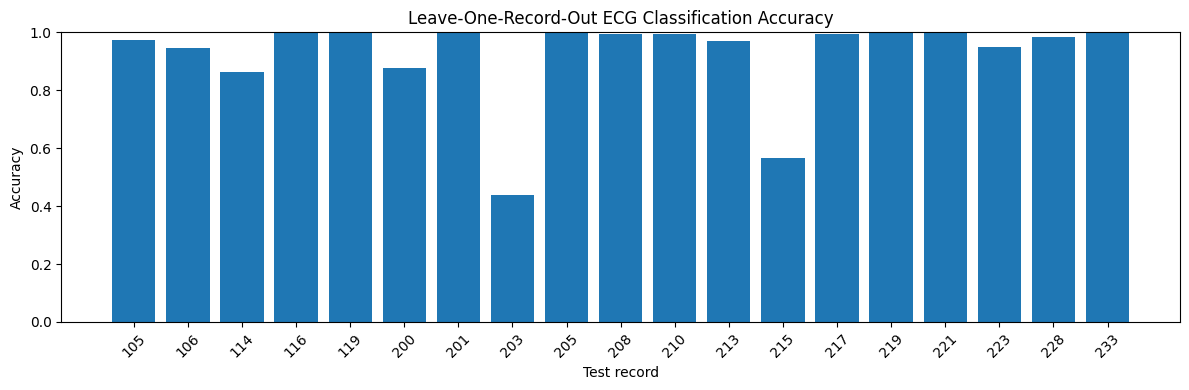

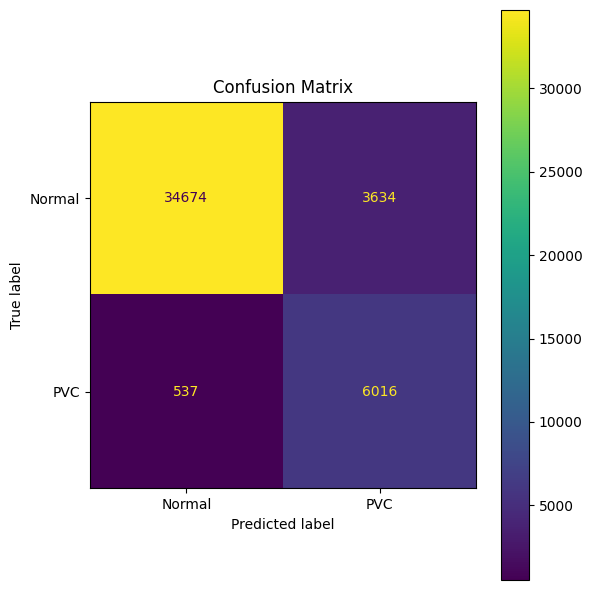

Results saved in the 'results' folder.


In [8]:
# Results and visualization

os.makedirs("results", exist_ok=True)

results_df = pd.DataFrame(fold_results)

display(results_df)

print("Mean accuracy:", results_df["accuracy"].mean())
print("Std accuracy:", results_df["accuracy"].std())

print("Mean PVC precision:", results_df["precision_pvc"].mean())
print("Mean PVC recall:", results_df["recall_pvc"].mean())
print("Mean PVC F1:", results_df["f1_pvc"].mean())

all_y_true = np.array(all_y_true)
all_y_pred = np.array(all_y_pred)

print("\nConfusion matrix:")
cm = confusion_matrix(all_y_true, all_y_pred)
print(cm)

print("\nClassification report:")
print(classification_report(
    all_y_true,
    all_y_pred,
    target_names=["Normal", "PVC"],
    zero_division=0
))

# Save fold results
results_df.to_csv("results/fold_results.csv", index=False)

# Save accuracy plot
plt.figure(figsize=(12, 4))
plt.bar(results_df["test_record"], results_df["accuracy"])
plt.xlabel("Test record")
plt.ylabel("Accuracy")
plt.title("Leave-One-Record-Out ECG Classification Accuracy")
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig("results/accuracy_plot.png", dpi=300)
plt.show()

# Save confusion matrix plot
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal", "PVC"]
)

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax)
plt.title("Confusion Matrix")
plt.tight_layout()
plt.savefig("results/confusion_matrix.png", dpi=300)
plt.show()

print("Results saved in the 'results' folder.")